Baseline-Modell: Logistische Regression

Ziel

In diesem Notebook wird zunächst ein einfaches Machine-Learning-Modell entwickelt.

Die Logistische Regression dient als Baseline und wird später mit dem neuronalen Netz verglichen.

Bibliotheken

In [3]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

Datensatz laden

In [4]:
matches = pd.read_csv("../data/processed/btts_features.csv")

matches.head()

,Div,Date,Time,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,...,LBCA,HomeGoalsLast5,AwayGoalsLast5,HomeConcededLast5,AwayConcededLast5,HomePoints,AwayPoints,HomeFormLast5,AwayFormLast5,BTTS
0,E0,2021-08-28,17:30,Liverpool,Chelsea,1,1,D,1,1,...,NaN,2.0,2.0,0.0,0.0,1,1,3.0,3.0,1
1,E0,2021-08-28,12:30,Man City,Arsenal,5,0,H,3,0,...,NaN,5.0,0.0,0.0,2.0,3,0,3.0,0.0,0
2,E0,2021-08-28,15:00,Aston Villa,Brentford,1,1,D,1,1,...,NaN,2.0,0.0,0.0,0.0,1,1,3.0,1.0,1
3,E0,2021-08-28,15:00,Brighton,Everton,0,2,A,0,1,...,NaN,2.0,2.0,0.0,2.0,0,3,3.0,1.0,0
4,E0,2021-08-28,15:00,Newcastle,Southampton,2,2,D,0,0,...,NaN,2.0,1.0,4.0,3.0,1,1,0.0,0.0,1


Feature und Zielvariable auswählen

In [7]:
features = [
    "HomeGoalsLast5",
    "AwayGoalsLast5",
    "HomeConcededLast5",
    "AwayConcededLast5",
    "HomeFormLast5",
    "AwayFormLast5"
]

X = matches[features]

y = matches ["BTTS"]

Trainings- und Testdatn

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(1492, 6)
(374, 6)


Modell trainieren

In [10]:
model = LogisticRegression()

model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [11]:
#Accuracy → Wie viele Spiele wurden insgesamt richtig vorhergesagt?
#Precision → Wie oft war eine BTTS-Vorhersage tatsächlich richtig?
#Recall → Wie viele tatsächliche BTTS-Spiele wurden erkannt?
#F1-Score → Kombination aus Precision und Recall.

y_pred = model.predict(X_test)

In [13]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))

Accuracy: 0.5481283422459893
Precision: 0.5722543352601156
Recall: 0.9041095890410958


In [15]:
# F1-Score berechnen

print("F1-Score:", f1_score(y_test, y_pred))

F1-Score: 0.7008849557522124


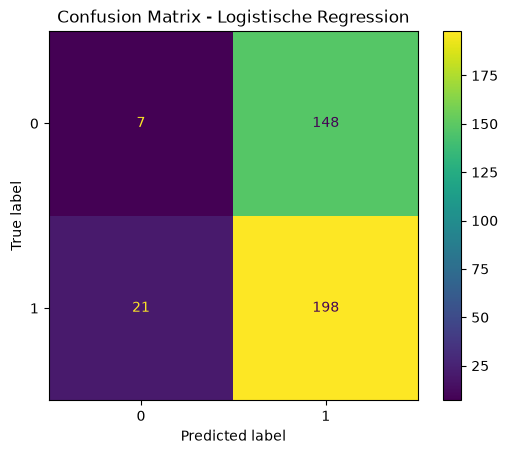

In [16]:
# Confusion Matrix

from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Confusion Matrix - Logistische Regression")
plt.show()